# Exercise 03 : Bar charts




In [1]:
import pandas as pd
import sqlite3

data = sqlite3.connect('../data/checking-logs.sqlite')

df = pd.read_sql_query("SELECT timestamp FROM checker WHERE uid LIKE 'user_%'", data)

data.close()

## Подготовка данных
#### Приведение форматов




In [2]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['timestamp'].dt.hour
df['weekday'] = df['timestamp'].dt.day_name()
df['is_weekend'] = df['timestamp'].dt.weekday >= 5

df_workdays = df[df['is_weekend'] == False].copy()
df_weekends = df[df['is_weekend'] == True].copy()

df

,timestamp,hour,weekday,is_weekend
0,2020-04-17 05:19:02.744528,5,Friday,False
1,2020-04-17 05:22:35.249331,5,Friday,False
2,2020-04-17 05:22:45.549397,5,Friday,False
3,2020-04-17 05:34:14.691200,5,Friday,False
4,2020-04-17 05:34:24.422370,5,Friday,False
...,...,...,...,...
3202,2020-05-21 20:19:06.872761,20,Thursday,False
3203,2020-05-21 20:22:41.785725,20,Thursday,False
3204,2020-05-21 20:22:41.877806,20,Thursday,False
3205,2020-05-21 20:37:00.129678,20,Thursday,False


#### Создание почасовой таблицы коммитов в будние дни




In [3]:
workdays_commits = df_workdays.groupby(['weekday', 'hour']).size().reset_index(name='commits')

df_workdays['date'] = df_workdays['timestamp'].dt.date
workdays_counts = df_workdays.groupby(['weekday', 'hour'])['date'].nunique().reset_index(name='days_count')

avg_workdays = workdays_commits.merge(workdays_counts, on=['weekday', 'hour'])
avg_workdays['workdays'] = avg_workdays['commits'] / avg_workdays['days_count']

avg_workdays_hourly = avg_workdays.groupby('hour')['workdays'].mean().reset_index()
avg_workdays_hourly

,hour,workdays
0,0,3.000000
1,3,2.000000
2,5,7.500000
3,6,1.500000
4,7,7.666667
5,8,3.750000
6,9,4.000000
7,10,11.791667
8,11,5.300000
9,12,7.133333


#### Создание почасовой таблицы коммитов в выходные дни





In [4]:
weekends_commits = df_weekends.groupby(['weekday', 'hour']).size().reset_index(name='commits')

df_weekends['date'] = df_weekends['timestamp'].dt.date
weekends_counts = df_weekends.groupby(['weekday', 'hour'])['date'].nunique().reset_index(name='days_count')

avg_weekends = weekends_commits.merge(weekends_counts, on=['weekday', 'hour'])
avg_weekends['weekends'] = avg_weekends['commits'] / avg_weekends['days_count']

avg_weekends_hourly = avg_weekends.groupby('hour')['weekends'].mean().reset_index()
avg_weekends_hourly

,hour,weekends
0,0,2.000000
1,1,6.000000
2,3,1.000000
3,5,2.000000
4,7,3.333333
5,8,7.000000
6,9,3.375000
7,10,5.000000
8,11,27.333333
9,12,9.500000


## Отрисовка графика





array([[<Axes: title={'center': 'weekends'}, xlabel='hour'>],
       [<Axes: title={'center': 'workdays'}, xlabel='hour'>]],
      dtype=object)

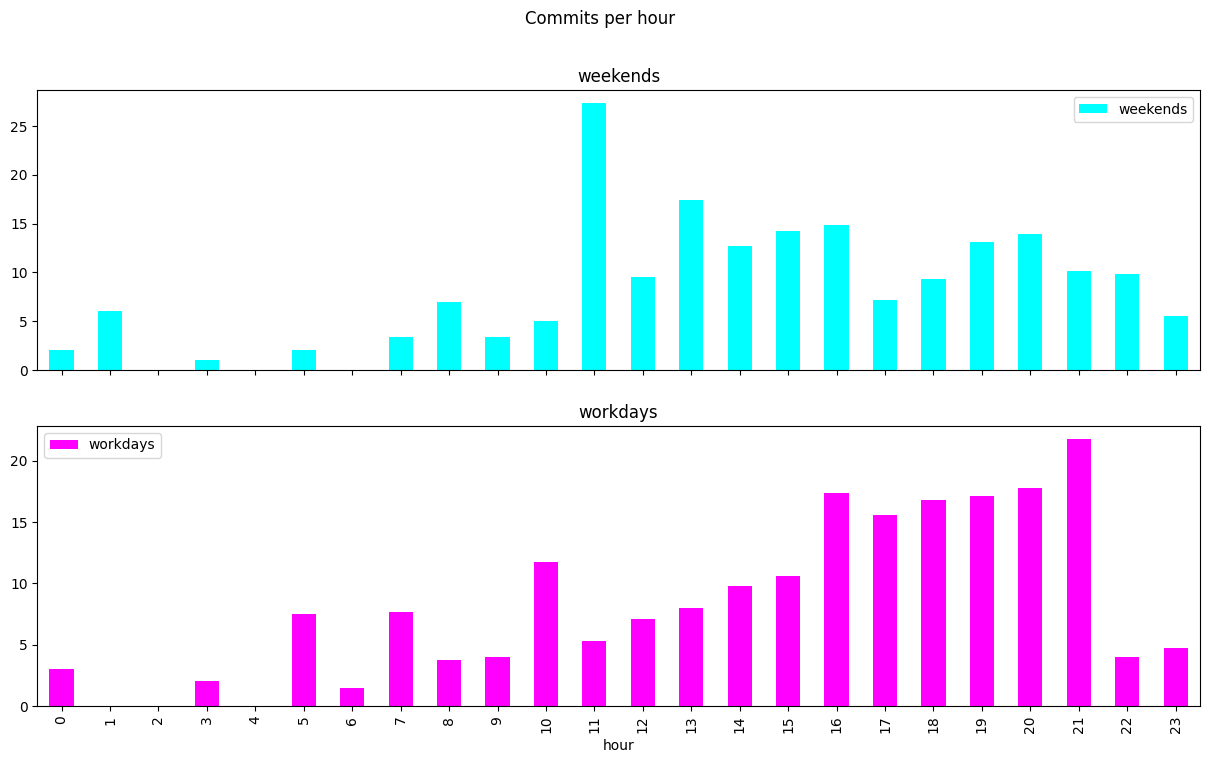

In [5]:
df_avg = avg_workdays_hourly.merge(avg_weekends_hourly, on='hour', how='outer').fillna(0)

all_hours = pd.DataFrame({'hour': range(24)})
df_avg = all_hours.merge(df_avg, on='hour', how='left').fillna(0)

df_avg.set_index('hour', inplace=True)
df_avg[['weekends', 'workdays']].plot(kind='bar', subplots=True, layout=(2,1), figsize=(15,8), colormap='cool', legend=True, title="Commits per hour")

## Is the dynamic different on working days and weekends?
#### Yes, most of the commits on weekends are in the afternoon (11), while on weekdays they are in the evening(21)


